# 📊 Analyse Exploratoire des Données

**Objectif** : Comprendre nos données sur les maladies cardiaques

Nous allons découvrir :
- À quoi ressemblent nos données
- Les statistiques de base
- Les relations entre les variables
- Les valeurs manquantes

In [15]:
# Importation des bibliothèques nécessaires
import pandas as pd  # Pour manipuler les données (comme Excel)
import numpy as np   # Pour les calculs mathématiques
import matplotlib.pyplot as plt  # Pour faire des graphiques
import seaborn as sns  # Pour des graphiques plus jolis
print("✅ Bibliothèques importées avec succès !")

✅ Bibliothèques importées avec succès !


In [16]:
# Charger nos données
# Le fichier CSV contient les informations sur les patients
df = pd.read_csv('../data/heart_disease_dataset.csv')

print("Données chargées avec succès !")
print(f" Notre dataset contient {df.shape[0]} patients et {df.shape[1]} variables")

# Afficher les premières lignes pour voir à quoi ressemblent les données
print("\n Aperçu des 5 premiers patients :")
df.head()

Données chargées avec succès !
 Notre dataset contient 1000 patients et 16 variables

 Aperçu des 5 premiers patients :


,Age,Gender,Cholesterol,Blood Pressure,Heart Rate,Smoking,Alcohol Intake,Exercise Hours,Family History,Diabetes,Obesity,Stress Level,Blood Sugar,Exercise Induced Angina,Chest Pain Type,Heart Disease
0,75,Female,228,119,66,Current,Heavy,1,No,No,Yes,8,119,Yes,Atypical Angina,1
1,48,Male,204,165,62,Current,NaN,5,No,No,No,9,70,Yes,Typical Angina,0
2,53,Male,234,91,67,Never,Heavy,3,Yes,No,Yes,5,196,Yes,Atypical Angina,1
3,69,Female,192,90,72,Current,NaN,4,No,Yes,No,7,107,Yes,Non-anginal Pain,0
4,62,Female,172,163,93,Never,NaN,6,No,Yes,No,2,183,Yes,Asymptomatic,0


In [17]:
print("Noms des colonnes :")
for i, col in enumerate(df.columns):
    print(f"{i+1:2d}. {col} : {df[col].dtype}")

Noms des colonnes :
 1. Age : int64
 2. Gender : object
 3. Cholesterol : int64
 4. Blood Pressure : int64
 5. Heart Rate : int64
 6. Smoking : object
 7. Alcohol Intake : object
 8. Exercise Hours : int64
 9. Family History : object
10. Diabetes : object
11. Obesity : object
12. Stress Level : int64
13. Blood Sugar : int64
14. Exercise Induced Angina : object
15. Chest Pain Type : object
16. Heart Disease : int64


In [19]:
# Statistiques descriptives de base
print("Statistiques descriptives :")
print("Ces chiffres nous donnent une idée générale de nos données")
df.describe().round(2)

Statistiques descriptives :
Ces chiffres nous donnent une idée générale de nos données


,Age,Cholesterol,Blood Pressure,Heart Rate,Exercise Hours,Stress Level,Blood Sugar,Heart Disease
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,52.29,249.94,135.28,79.20,4.53,5.65,134.94,0.39
std,15.73,57.91,26.39,11.49,2.93,2.83,36.70,0.49
min,25.00,150.00,90.00,60.00,0.00,1.00,70.00,0.00
25%,39.00,200.00,112.75,70.00,2.00,3.00,104.00,0.00
50%,52.00,248.00,136.00,79.00,4.50,6.00,135.00,0.00
75%,66.00,299.00,159.00,89.00,7.00,8.00,167.00,1.00
max,79.00,349.00,179.00,99.00,9.00,10.00,199.00,1.00


In [26]:
print("Vérification des valeurs manquantes :")
missing_values = df.isnull().sum()

if missing_values.sum() == 0:
    print("Parfait ! Il n'y a pas de valeurs manquantes")
else:
    print("Valeurs manquantes trouvées :")
    print(missing_values[missing_values > 0])

Vérification des valeurs manquantes :
Valeurs manquantes trouvées :
Alcohol Intake    340
dtype: int64


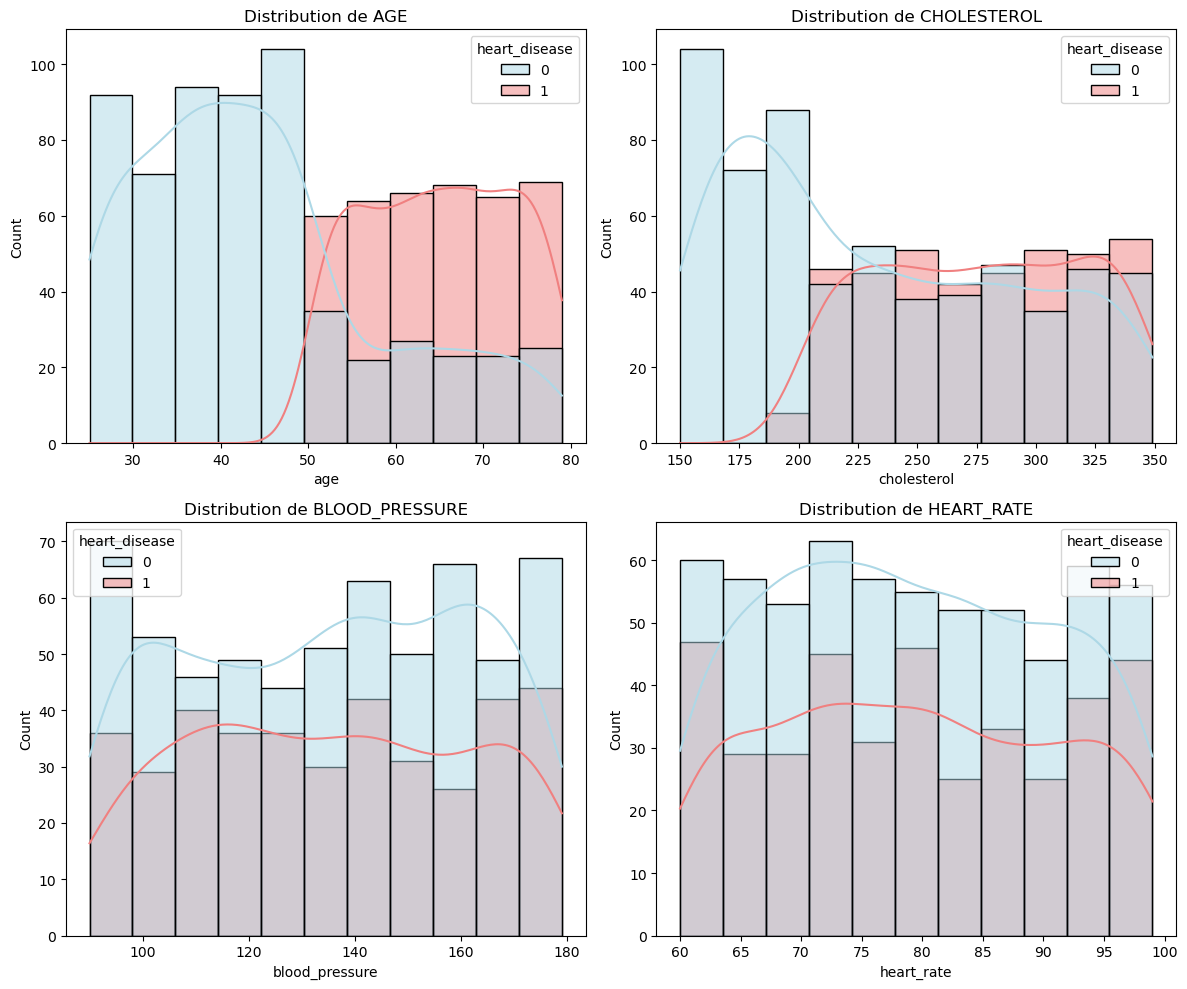

In [30]:
# Nettoyage des colonnes
df.columns = df.columns.str.lower().str.replace(" ", "_")

# Variables à analyser
variables = ['age', 'cholesterol', 'blood_pressure', 'heart_rate']

# Création des subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

# Plot
for i, var in enumerate(variables):
    sns.histplot(data=df, x=var, hue='heart_disease',
                 kde=True,
                 palette=['lightblue', 'lightcoral'],
                 ax=axes[i])

    axes[i].set_title(f'Distribution de {var.upper()}')

plt.tight_layout()
plt.show()

 Matrice de corrélation :
Les valeurs proches de 1 ou -1 indiquent une forte relation
Les valeurs proches de 0 indiquent une faible relation


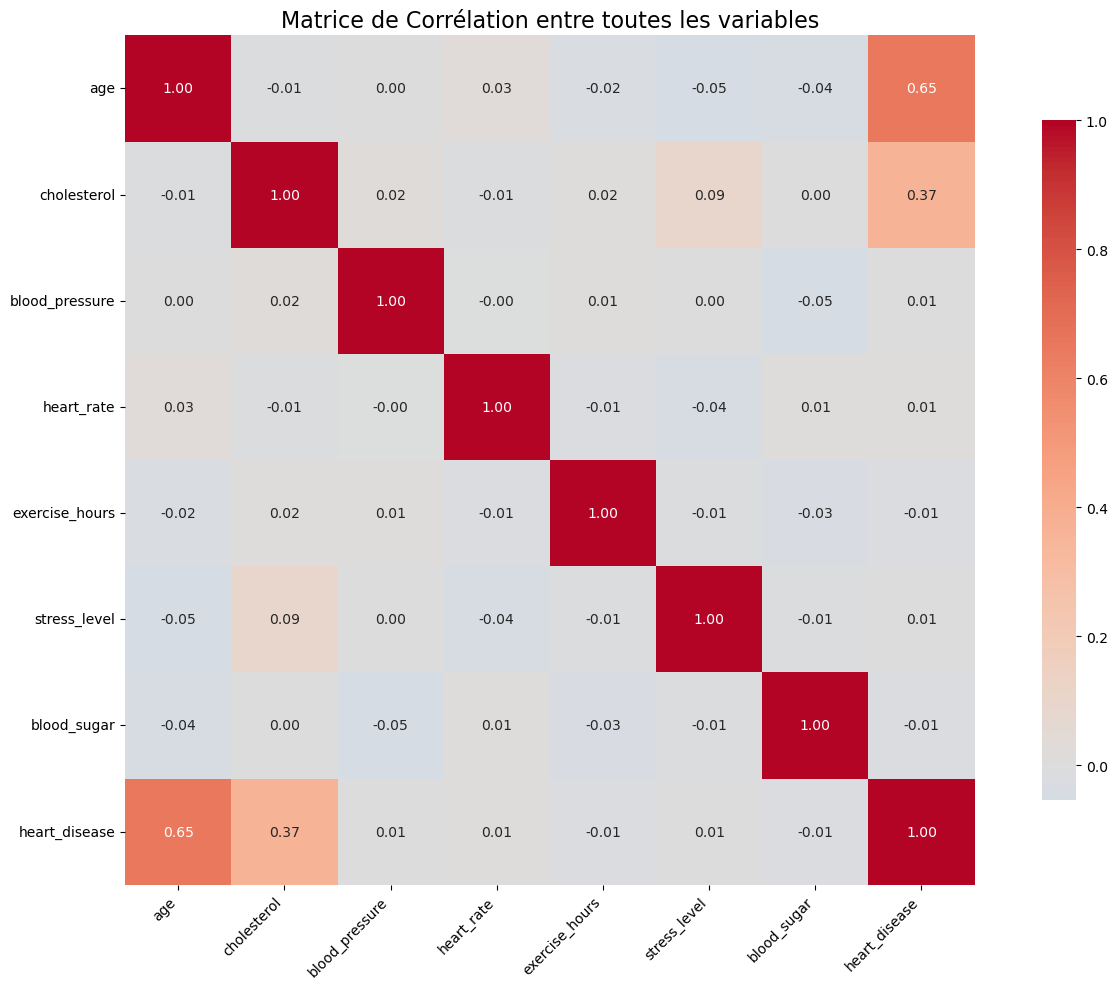


 Corrélations les plus fortes avec la maladie cardiaque :
age               0.646871
cholesterol       0.365041
exercise_hours   -0.014226
heart_rate        0.013209
blood_sugar      -0.013004
stress_level      0.007071
blood_pressure    0.006900
Name: heart_disease, dtype: float64


In [40]:
#  Nettoyage des noms de colonnes
df.columns = df.columns.str.lower().str.strip().str.replace(" ", "_")

print(" Matrice de corrélation :")
print("Les valeurs proches de 1 ou -1 indiquent une forte relation")
print("Les valeurs proches de 0 indiquent une faible relation")

#  Garder uniquement les colonnes numériques
df_numeric = df.select_dtypes(include=['int64', 'float64'])

#  Calcul de la corrélation
correlation_matrix = df_numeric.corr()

# Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    square=True,
    fmt='.2f',
    cbar_kws={"shrink": .8}
)

plt.title('Matrice de Corrélation entre toutes les variables', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Corrélation avec la variable cible
print("\n Corrélations les plus fortes avec la maladie cardiaque :")

target_correlations = correlation_matrix['heart_disease'].sort_values(key=abs, ascending=False)

print(target_correlations.drop('heart_disease').head(10))

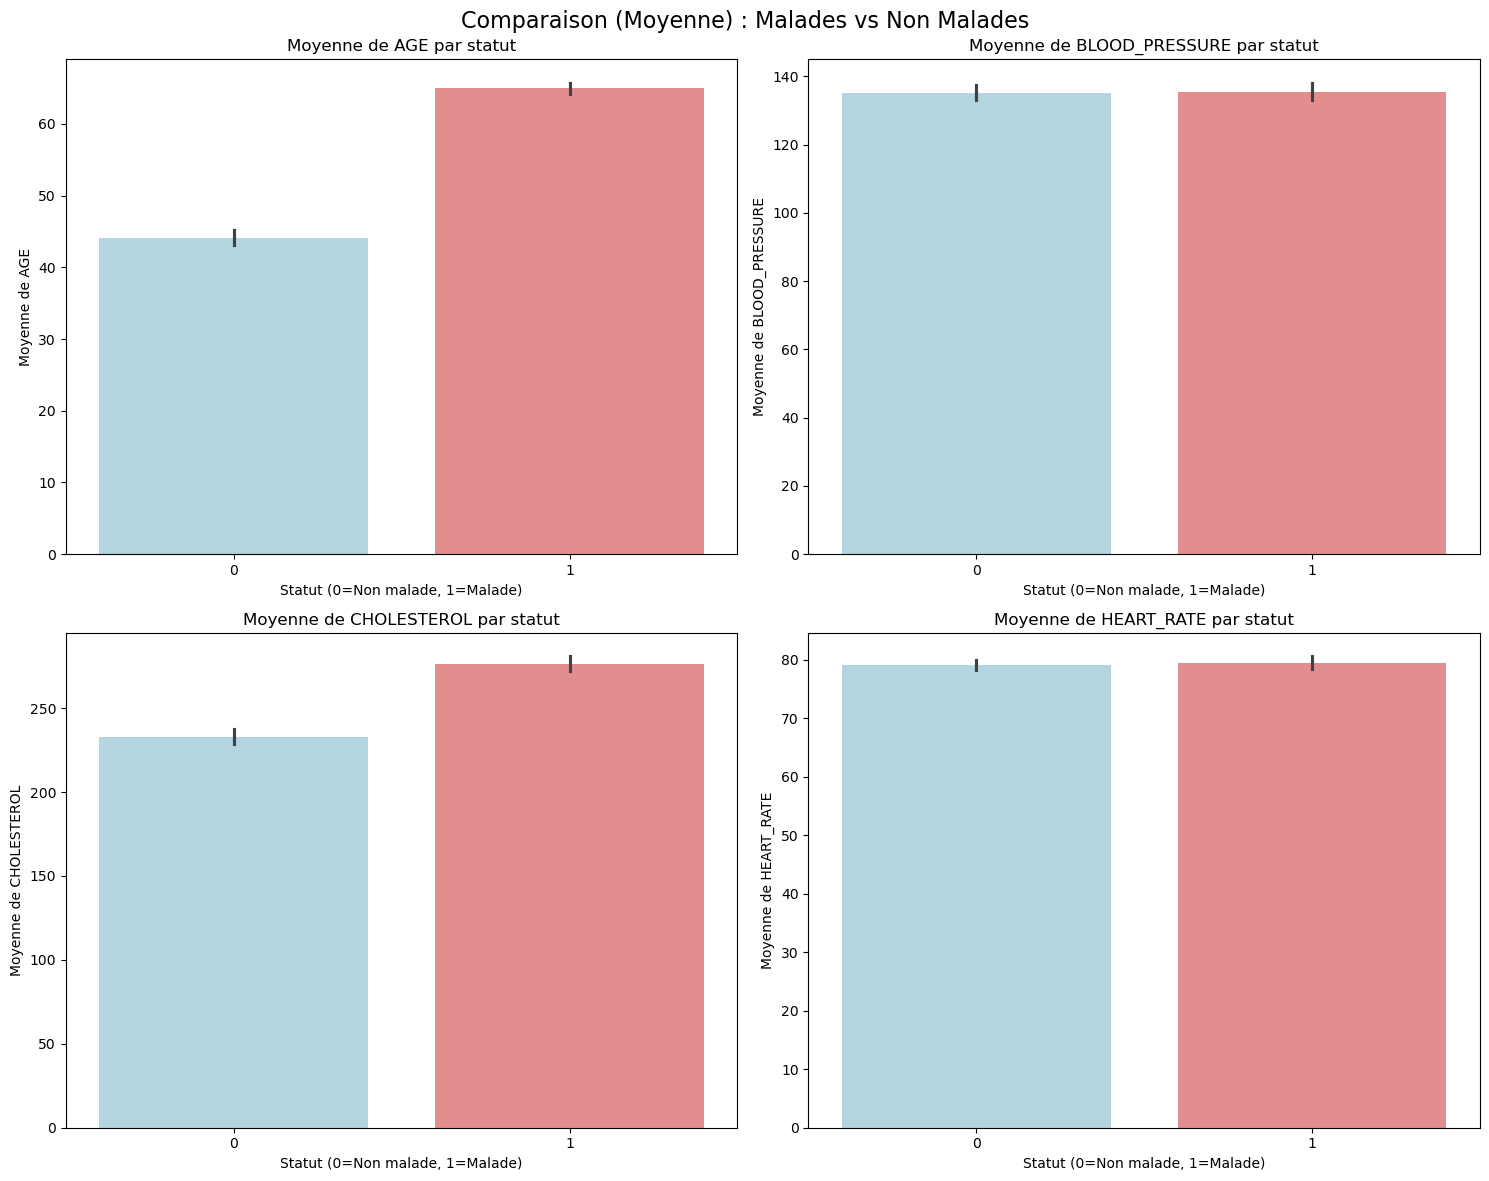

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

df.columns = df.columns.str.lower().str.strip().str.replace(" ", "_")

vars_to_compare = ['age', 'blood_pressure', 'cholesterol', 'heart_rate']

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Comparaison (Moyenne) : Malades vs Non Malades', fontsize=16)

for i, var in enumerate(vars_to_compare):
    row = i // 2
    col = i % 2

    sns.barplot(
        data=df,
        x='heart_disease',
        y=var,
        hue='heart_disease',
        palette=['lightblue', 'lightcoral'],
        legend=False,
        ax=axes[row, col]
    )

    axes[row, col].set_title(f'Moyenne de {var.upper()} par statut')
    axes[row, col].set_xlabel('Statut (0=Non malade, 1=Malade)')
    axes[row, col].set_ylabel(f'Moyenne de {var.upper()}')

plt.tight_layout()
plt.show()

 Distribution des patients par présence de maladie cardiaque :
heart_disease
0    608
1    392
Name: count, dtype: int64

 Pourcentages :
Non malade: 60.8%
Malade: 39.2%


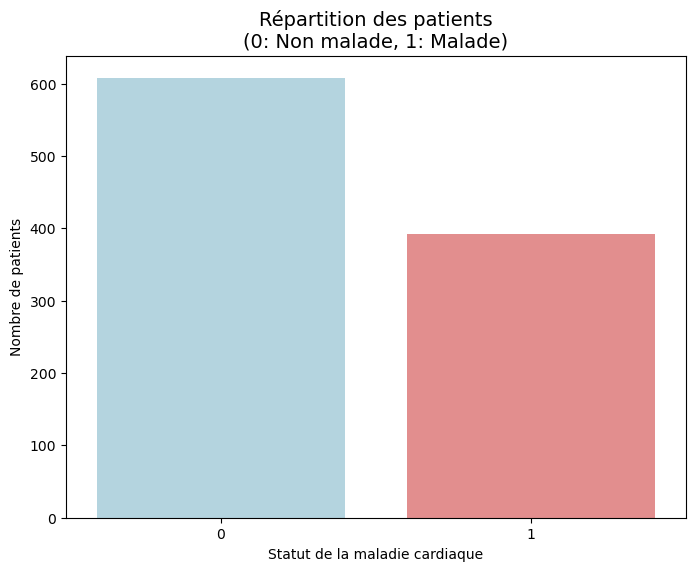

In [53]:
# Nettoyer les colonnes (à faire UNE fois au début)
df.columns = df.columns.str.lower().str.strip().str.replace(" ", "_")

print(" Distribution des patients par présence de maladie cardiaque :")

#  Utiliser le bon nom
target_counts = df['heart_disease'].value_counts()
print(target_counts)

# Pourcentages
target_percentages = df['heart_disease'].value_counts(normalize=True) * 100
print("\n Pourcentages :")

for idx, pct in target_percentages.items():
    status = "Malade" if idx == 1 else "Non malade"
    print(f"{status}: {pct:.1f}%")

# Visualisation corrigée (sans warning)
plt.figure(figsize=(8, 6))

sns.countplot(
    data=df,
    x='heart_disease',
    hue='heart_disease',   
    palette=['lightblue', 'lightcoral'],
    legend=False
)

plt.title('Répartition des patients\n(0: Non malade, 1: Malade)', fontsize=14)
plt.xlabel('Statut de la maladie cardiaque')
plt.ylabel('Nombre de patients')

plt.show()